# 선택 과제: 기본 클래스 상속

엣지·가입 코호트는 가입일과 RGB 배열이 함께 있는 교육용 합성 샘플로 검증했다. 공개 거래에는 가입일이 없어 첫 구매일을 가입일로 바꾸지 않았다. Plotly는 기본 분석과 동일한 공개 거래의 RFM을 표시했다.

In [1]:
from pathlib import Path
import os
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ['MPLCONFIGDIR'] = str(ROOT / '.cache' / 'matplotlib')
os.environ['XDG_CACHE_HOME'] = str(ROOT / '.cache' / 'xdg')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from src.pipeline import DataAnalyzer
%matplotlib inline
sns.set_theme(style='whitegrid')
FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
print('Python:', sys.version.split()[0], '|', sys.executable)

from src.bonus_pipeline import BonusDataAnalyzer
bonus = BonusDataAnalyzer(ROOT / 'data/sample/orders.csv', ROOT / 'data/sample/images.npy')
bonus.load_data()
bonus.handle_missing_values()
bonus.engineer_features()

Python: 3.12.2 | /Users/oliverjoo/Dev/Anaconda/anaconda3/envs/py312/bin/python


,order_id,customer_id,product_name,category,price,qty,amount,order_date,signup_date,image_index,image_mean,image_std,product_word_count
0,1,C0,Electronics item 42,Electronics,46000.000000,1,46000,2026-01-17,2026-01-16,42,197.807292,14.660724,3
1,2,C0,Beauty item 22,Beauty,30000.000000,2,60000,2026-02-09,2026-01-16,22,119.578125,16.140146,3
2,3,C0,Electronics item 47,Electronics,51000.000000,1,51000,2026-03-05,2026-01-16,47,215.640625,15.862397,3
3,4,C0,Electronics item 36,Electronics,40000.000000,2,80000,2026-03-28,2026-01-16,36,173.510417,16.831267,3
4,5,C0,Sports item 31,Sports,39551.724138,2,74000,2026-04-20,2026-01-16,31,154.421875,16.174637,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1436,C238,Home item 1,Home,11000.000000,1,11000,2026-04-25,2026-03-22,1,34.010417,17.502973,3
1436,1437,C239,Beauty item 16,Beauty,24000.000000,3,72000,2026-03-05,2026-03-04,16,95.281250,16.569112,3
1437,1438,C239,Sports item 35,Sports,41000.000000,2,82000,2026-04-02,2026-03-04,35,169.171875,17.472199,3
1438,1439,C239,Home item 7,Home,17000.000000,1,17000,2026-05-01,2026-03-04,7,60.213542,16.003295,3


## 1. NumPy 엣지 특성

가로와 세로 인접 픽셀 차이의 절댓값 평균을 평균냅니다. `uint8`에서 0−255가 순환하지 않도록 먼저 실수형으로 바꿉니다.

In [2]:
bonus.add_edge_features()
display(bonus.df[['image_mean', 'image_std', 'image_edge']].describe())
print('Average edge strength:', bonus.df.image_edge.mean())

,image_mean,image_std,image_edge
count,1440.000000,1440.000000,1440.000000
mean,122.797993,16.031516,18.229154
std,55.530129,0.805291,1.222081
min,29.703125,14.139211,16.026786
25%,73.895833,15.357710,17.366071
50%,119.578125,16.103910,18.303571
75%,173.510417,16.609119,18.970238
max,216.484375,17.513102,22.529762


Average edge strength: 18.229154265873014


**해석:** 8×8 RGB 배열에서 방향당 168개 인접 채널 차이를 비교한다. 이 값은 합성 노이즈의 변화량이며 실제 상품 선명도나 구매 전환율은 아니다.

## 2. 가입 월별 재구매율

분모는 해당 가입 월의 고객 수, 분자는 경과 월에 두 번째 이후 주문을 한 고유 고객 수이다. 늦은 첫 구매를 재구매로 세지 않는다. 미래 월은 NaN으로 가립니다. 샘플은 모든 가입자에게 주문이 있어 분모를 거래표에서 얻을 수 있다. 실제 서비스에는 미구매 가입자를 포함한 회원표가 필요한다.

age,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2026-01,0.044,0.867,0.800,0.933,0.800,0.711,0.667,0.600,0.311
2026-02,0.088,0.985,0.926,0.912,0.809,0.662,0.588,0.397,NaN
2026-03,0.226,1.000,0.943,0.755,0.679,0.566,0.283,NaN,NaN
2026-04,1.000,0.929,0.643,0.571,0.286,0.286,NaN,NaN,NaN
2026-08,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-09,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


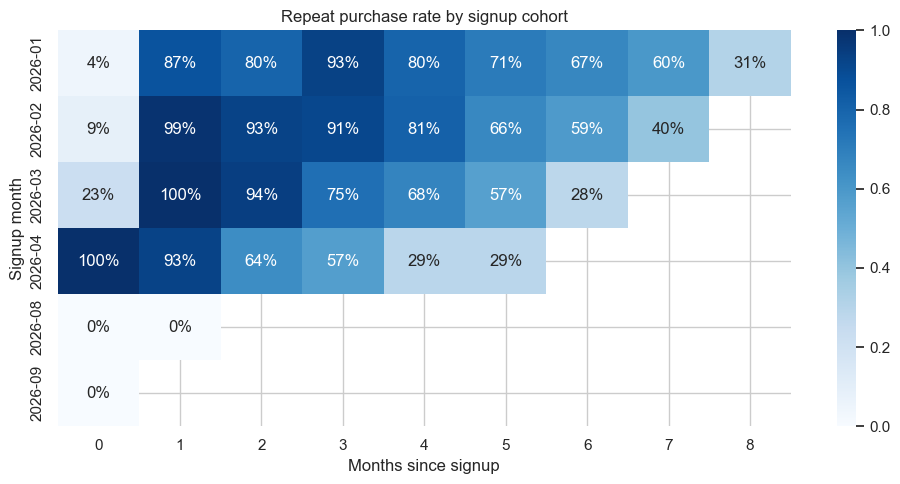

In [3]:
retention = bonus.cohort_retention()
display(retention.round(3))
retention.to_csv(ROOT / 'reports/cohort_retention.csv')
fig = bonus.plot_cohort(retention)
fig.savefig(FIGURES / '07_cohort.png', dpi=140)
plt.show()

**해석:** 관측 기간은 2026년 1~9월의 9개월이다. 단일 구매 고객의 재구매 횟수는 0이다. 연속 유지율이나 첫 구매 코호트와는 다른 지표이며, 월중 분석이라면 마지막 달은 불완전할 수 있다. 고객 수가 작은 가입 월의 비율은 크게 흔들릴 수 있다.

## 3. Plotly RFM 시각화

색은 세그먼트, 점 크기는 구매 횟수이다. 마우스로 고객 ID를 확인하고 범례로 그룹을 선택할 수 있다. HTML에 Plotly 실행 코드를 포함하여 인터넷 없이 열 수 있다.

In [4]:
retail = BonusDataAnalyzer(ROOT / 'data/orders.csv', ROOT / 'data/images.npy')
retail.load_data()
rfm = retail.segment_customers(retail.calculate_rfm())
figure = retail.plot_rfm(rfm, currency='GBP')
figure.write_html(ROOT / 'reports/rfm_interactive.html', include_plotlyjs=True, full_html=True)
figure.show()

**해석:** 공개 거래의 고객 240명 중 VIP 58명은 평균 10.21회 구매했다. 큰 점은 많은 주문을 의미하며 미래 매출을 예측하는 모델은 아니다.